# CSCI E-89 Assignment 03 - Problem 4
### Author: Carlos Fernandez

Code generated with OpenAI Codex. Each code cell is labelled with the script it comes from.

In [1]:
import sys
sys.path.insert(0, 'scripts')

## step1_setup.py

**What was done and why:** Configure reproducible PyTorch setup and report the selected compute device.

This establishes a consistent starting point for the Fashion-MNIST classifier.

In [2]:
# ===== Notebook cell for generated script: scripts\step1_setup.py =====
"""Configure reproducible PyTorch setup and report the selected compute device.

This establishes a consistent starting point for the Fashion-MNIST classifier.
"""

import platform
import random

import numpy as np
import torch


def set_seed(seed=42):
    """Seed Python, NumPy, and PyTorch random number generators."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def get_device():
    """Select CUDA, then MPS, and otherwise CPU when available."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def print_environment(device):
    """Print the software versions and selected PyTorch device."""
    print(f"Python version: {platform.python_version()}")
    print(f"NumPy version: {np.__version__}")
    print(f"PyTorch version: {torch.__version__}")
    print(f"Device: {device}")


if __name__ == "__main__":
    set_seed(42)
    device = get_device()
    print_environment(device)


Python version: 3.11.16
NumPy version: 2.4.6
PyTorch version: 2.14.0+cpu
Device: cpu


## step2_data.py

**What was done and why:** Load and inspect Fashion-MNIST data for the image classifier.

The images are scaled to float32 values in [0, 1] so the model receives
consistent inputs, and the training data is split for validation.

In [3]:
# ===== Notebook cell for generated script: scripts\step2_data.py =====
__file__ = r"scripts/step2_data.py"  # notebooks have no __file__, so define it here
"""Load and inspect Fashion-MNIST data for the image classifier.

The images are scaled to float32 values in [0, 1] so the model receives
consistent inputs, and the training data is split for validation.
"""

from pathlib import Path

import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets
from torchvision.transforms import v2


DATA_DIR = Path(__file__).resolve().parents[1] / "data"
BATCH_SIZE = 32
TRAIN_SIZE = 55_000
SEED = 42


def get_transform():
    """Create the image transform used for Fashion-MNIST examples."""
    return v2.Compose(
        [
            v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True),
        ]
    )


def load_datasets(data_dir=DATA_DIR):
    """Download Fashion-MNIST and return its training and test datasets."""
    transform = get_transform()
    train_dataset = datasets.FashionMNIST(
        root=data_dir, train=True, download=True, transform=transform
    )
    test_dataset = datasets.FashionMNIST(
        root=data_dir, train=False, download=True, transform=transform
    )
    return train_dataset, test_dataset


def make_dataloaders(train_dataset, test_dataset, batch_size=BATCH_SIZE, seed=SEED):
    """Split training examples and create train, validation, and test loaders."""
    validation_size = len(train_dataset) - TRAIN_SIZE
    generator = torch.Generator().manual_seed(seed)
    train_dataset, validation_dataset = random_split(
        train_dataset, [TRAIN_SIZE, validation_size], generator=generator
    )
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, validation_loader, test_loader


def print_data_summary(train_loader, validation_loader, test_loader, class_names):
    """Print split details and inspect one batch from the training loader."""
    images, labels = next(iter(train_loader))
    print(f"Training examples: {len(train_loader.dataset)}")
    print(f"Validation examples: {len(validation_loader.dataset)}")
    print(f"Test examples: {len(test_loader.dataset)}")
    print(f"Image batch shape: {images.shape}")
    print(f"Label batch shape: {labels.shape}")
    print(f"Image batch dtype: {images.dtype}")
    print(f"Label batch dtype: {labels.dtype}")
    print(f"Pixel value range: [{images.min().item():.1f}, {images.max().item():.1f}]")
    print(f"Class names: {class_names}")


if __name__ == "__main__":
    train_dataset, test_dataset = load_datasets()
    train_loader, validation_loader, test_loader = make_dataloaders(
        train_dataset, test_dataset
    )
    print_data_summary(
        train_loader, validation_loader, test_loader, train_dataset.classes
    )


Training examples: 55000
Validation examples: 5000
Test examples: 10000
Image batch shape: torch.Size([32, 1, 28, 28])
Label batch shape: torch.Size([32])
Image batch dtype: torch.float32
Label batch dtype: torch.int64
Pixel value range: [0.0, 1.0]
Class names: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## step3_model.py

**What was done and why:** Define the multilayer perceptron used to classify Fashion-MNIST images.

The network maps flattened 28-by-28 images to ten raw class logits for use
with cross-entropy loss during training.

In [4]:
# ===== Notebook cell for generated script: scripts\step3_model.py =====
"""Define the multilayer perceptron used to classify Fashion-MNIST images.

The network maps flattened 28-by-28 images to ten raw class logits for use
with cross-entropy loss during training.
"""

import torch
from torch import nn


class ImageClassifier(nn.Module):
    """A 784-300-100-10 multilayer perceptron image classifier."""

    def __init__(
        self,
        input_size=784,
        first_hidden_size=300,
        second_hidden_size=100,
        num_classes=10,
    ):
        super().__init__()
        self.hyperparameters = {
            "input_size": input_size,
            "first_hidden_size": first_hidden_size,
            "second_hidden_size": second_hidden_size,
            "num_classes": num_classes,
        }
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, first_hidden_size),
            nn.ReLU(),
            nn.Linear(first_hidden_size, second_hidden_size),
            nn.ReLU(),
            nn.Linear(second_hidden_size, num_classes),
        )

    def forward(self, images):
        """Return unnormalized class scores for a batch of images."""
        return self.layers(images)


def build_model(**hyperparameters):
    """Build a new ImageClassifier instance."""
    return ImageClassifier(**hyperparameters)


def count_parameters(model):
    """Return the number of trainable parameters in a model."""
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


if __name__ == "__main__":
    batch_size = 32
    model = build_model()
    images = torch.rand(batch_size, 1, 28, 28)
    output = model(images)
    parameter_count = count_parameters(model)

    assert output.shape == (batch_size, 10)
    assert parameter_count == 266_610

    print(f"Output shape: {output.shape}")
    print(f"Trainable parameters: {parameter_count:,}")


Output shape: torch.Size([32, 10])
Trainable parameters: 266,610


## step4_train.py

**What was done and why:** Train the Fashion-MNIST image classifier with a manual PyTorch loop.

This records loss and accuracy after each epoch so learning progress can be
inspected and plotted in the next step.

In [5]:
# ===== Notebook cell for generated script: scripts\step4_train.py =====
"""Train the Fashion-MNIST image classifier with a manual PyTorch loop.

This records loss and accuracy after each epoch so learning progress can be
inspected and plotted in the next step.
"""

import torch
from torch import nn

from step1_setup import get_device, set_seed
from step2_data import BATCH_SIZE, load_datasets, make_dataloaders
from step3_model import build_model


EPOCHS = 10
LEARNING_RATE = 0.1


def evaluate(model, data_loader, loss_function, device):
    """Return average loss and accuracy for a validation data loader."""
    model.eval()
    total_loss = 0.0
    correct_predictions = 0
    total_examples = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            loss = loss_function(logits, labels)

            total_loss += loss.item() * labels.size(0)
            correct_predictions += (logits.argmax(dim=1) == labels).sum().item()
            total_examples += labels.size(0)

    return total_loss / total_examples, correct_predictions / total_examples


def train_model(
    model,
    train_loader,
    validation_loader,
    device,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
):
    """Train a model with SGD and return per-epoch loss and accuracy history."""
    loss_function = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    history = {
        "train_loss": [],
        "train_accuracy": [],
        "validation_loss": [],
        "validation_accuracy": [],
    }
    model.to(device)

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        correct_predictions = 0
        total_examples = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = loss_function(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * labels.size(0)
            correct_predictions += (logits.argmax(dim=1) == labels).sum().item()
            total_examples += labels.size(0)

        train_loss = total_loss / total_examples
        train_accuracy = correct_predictions / total_examples
        validation_loss, validation_accuracy = evaluate(
            model, validation_loader, loss_function, device
        )

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["validation_loss"].append(validation_loss)
        history["validation_accuracy"].append(validation_accuracy)
        print(
            f"Epoch {epoch:2d}/{epochs}: "
            f"train loss={train_loss:.4f}, train accuracy={train_accuracy:.2%}, "
            f"validation loss={validation_loss:.4f}, "
            f"validation accuracy={validation_accuracy:.2%}"
        )

    return history


if __name__ == "__main__":
    set_seed(42)
    device = get_device()
    train_dataset, test_dataset = load_datasets()
    train_loader, validation_loader, _ = make_dataloaders(
        train_dataset, test_dataset, batch_size=BATCH_SIZE
    )
    model = build_model()
    history = train_model(model, train_loader, validation_loader, device)

    assert history["validation_accuracy"][-1] > 0.80


Epoch  1/10: train loss=0.6062, train accuracy=78.12%, validation loss=0.4433, validation accuracy=84.20%


Epoch  2/10: train loss=0.4060, train accuracy=84.92%, validation loss=0.4289, validation accuracy=83.88%


Epoch  3/10: train loss=0.3631, train accuracy=86.55%, validation loss=0.3957, validation accuracy=85.24%


Epoch  4/10: train loss=0.3348, train accuracy=87.68%, validation loss=0.3650, validation accuracy=86.50%


Epoch  5/10: train loss=0.3142, train accuracy=88.40%, validation loss=0.3350, validation accuracy=87.88%


Epoch  6/10: train loss=0.2994, train accuracy=88.73%, validation loss=0.3561, validation accuracy=86.62%


Epoch  7/10: train loss=0.2851, train accuracy=89.31%, validation loss=0.3400, validation accuracy=87.36%


Epoch  8/10: train loss=0.2744, train accuracy=89.61%, validation loss=0.3390, validation accuracy=87.58%


Epoch  9/10: train loss=0.2634, train accuracy=90.14%, validation loss=0.3316, validation accuracy=88.10%


Epoch 10/10: train loss=0.2535, train accuracy=90.35%, validation loss=0.3518, validation accuracy=87.50%


## step5_plot.py

**What was done and why:** Plot Fashion-MNIST training curves to visualize model learning progress.

The accuracy and loss plots make it easy to compare training with validation
performance and identify possible overfitting.

Epoch  1/3: train loss=0.6062, train accuracy=78.12%, validation loss=0.4433, validation accuracy=84.20%


Epoch  2/3: train loss=0.4060, train accuracy=84.92%, validation loss=0.4289, validation accuracy=83.88%


Epoch  3/3: train loss=0.3631, train accuracy=86.55%, validation loss=0.3957, validation accuracy=85.24%


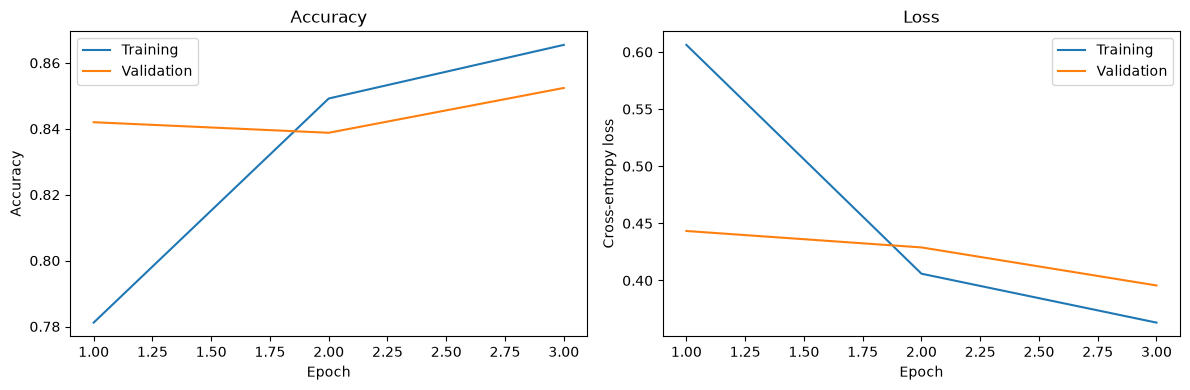

In [6]:
# ===== Notebook cell for generated script: scripts\step5_plot.py =====
__file__ = r"scripts/step5_plot.py"  # notebooks have no __file__, so define it here
"""Plot Fashion-MNIST training curves to visualize model learning progress.

The accuracy and loss plots make it easy to compare training with validation
performance and identify possible overfitting.
"""

from pathlib import Path

import matplotlib.pyplot as plt

from step1_setup import get_device, set_seed
from step2_data import BATCH_SIZE, load_datasets, make_dataloaders
from step3_model import build_model
from step4_train import train_model


OUTPUT_PATH = Path(__file__).with_name("training_curves.png")


def plot_history(history, output_path=OUTPUT_PATH):
    """Plot accuracy and loss histories, then save and display the figure."""
    epochs = range(1, len(history["train_accuracy"]) + 1)
    figure, (accuracy_axis, loss_axis) = plt.subplots(1, 2, figsize=(12, 4))

    accuracy_axis.plot(epochs, history["train_accuracy"], label="Training")
    accuracy_axis.plot(epochs, history["validation_accuracy"], label="Validation")
    accuracy_axis.set_title("Accuracy")
    accuracy_axis.set_xlabel("Epoch")
    accuracy_axis.set_ylabel("Accuracy")
    accuracy_axis.legend()

    loss_axis.plot(epochs, history["train_loss"], label="Training")
    loss_axis.plot(epochs, history["validation_loss"], label="Validation")
    loss_axis.set_title("Loss")
    loss_axis.set_xlabel("Epoch")
    loss_axis.set_ylabel("Cross-entropy loss")
    loss_axis.legend()

    figure.tight_layout()
    figure.savefig(output_path)
    plt.show()


if __name__ == "__main__":
    set_seed(42)
    device = get_device()
    train_dataset, test_dataset = load_datasets()
    train_loader, validation_loader, _ = make_dataloaders(
        train_dataset, test_dataset, batch_size=BATCH_SIZE
    )
    history = train_model(
        build_model(), train_loader, validation_loader, device, epochs=3
    )
    plot_history(history)


Plot saved by `step5_plot.py`, displayed here so it appears in the notebook and the HTML export:

scripts\training_curves.png


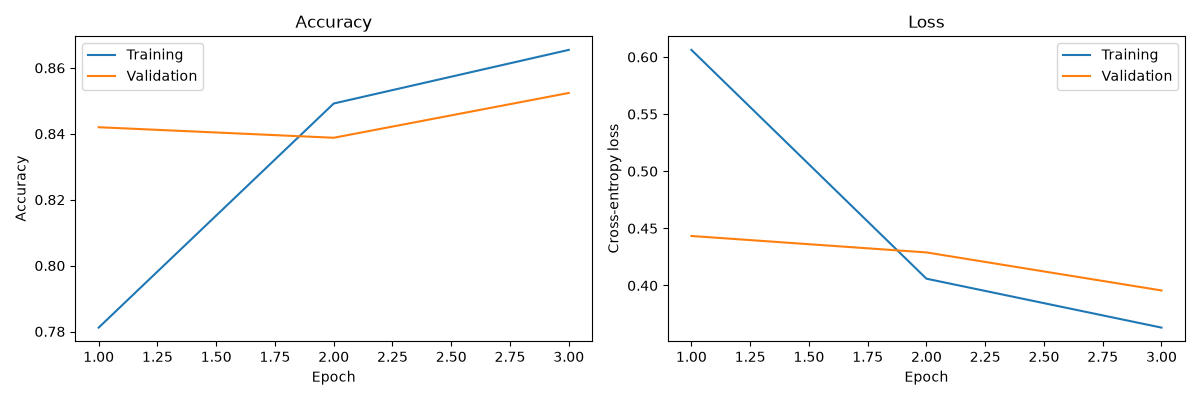

In [7]:
from IPython.display import Image, display
import glob
for f in sorted(glob.glob('**/*.png', recursive=True)):
    print(f)
    display(Image(filename=f))

## step6_evaluate.py

**What was done and why:** Evaluate the trained Fashion-MNIST classifier once on the held-out test set.

This reports final test accuracy and interprets a few predictions using class
names and softmax probabilities after training has finished.

In [8]:
# ===== Notebook cell for generated script: scripts\step6_evaluate.py =====
"""Evaluate the trained Fashion-MNIST classifier once on the held-out test set.

This reports final test accuracy and interprets a few predictions using class
names and softmax probabilities after training has finished.
"""

import torch

from step1_setup import get_device, set_seed
from step2_data import BATCH_SIZE, load_datasets, make_dataloaders
from step3_model import build_model
from step4_train import train_model


def evaluate_test_set(model, test_loader, class_names, device, examples_to_print=3):
    """Print final test accuracy and predictions for a few test images."""
    model.eval()
    correct_predictions = 0
    total_examples = 0
    examples = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            predicted_labels = logits.argmax(dim=1)

            correct_predictions += (predicted_labels == labels).sum().item()
            total_examples += labels.size(0)

            remaining_examples = examples_to_print - len(examples)
            for image_logits, predicted_label, true_label in zip(
                logits[:remaining_examples],
                predicted_labels[:remaining_examples],
                labels[:remaining_examples],
            ):
                probabilities = torch.softmax(image_logits, dim=0)
                top_probabilities, top_labels = probabilities.topk(3)
                top_three = [
                    f"{class_names[label.item()]}: {probability.item():.2%}"
                    for probability, label in zip(top_probabilities, top_labels)
                ]
                examples.append(
                    (
                        class_names[predicted_label.item()],
                        class_names[true_label.item()],
                        top_three,
                    )
                )

    test_accuracy = correct_predictions / total_examples
    print(f"Test accuracy: {test_accuracy:.2%}")
    for number, (predicted_class, true_class, top_three) in enumerate(examples, start=1):
        print(f"Test image {number}:")
        print(f"  Predicted class: {predicted_class}")
        print(f"  True class: {true_class}")
        print(f"  Top-3 softmax probabilities: {', '.join(top_three)}")

    return test_accuracy


if __name__ == "__main__":
    set_seed(42)
    device = get_device()
    train_dataset, test_dataset = load_datasets()
    train_loader, validation_loader, test_loader = make_dataloaders(
        train_dataset, test_dataset, batch_size=BATCH_SIZE
    )
    model = build_model()
    train_model(model, train_loader, validation_loader, device)
    evaluate_test_set(model, test_loader, test_dataset.classes, device)


Epoch  1/10: train loss=0.6062, train accuracy=78.12%, validation loss=0.4433, validation accuracy=84.20%


Epoch  2/10: train loss=0.4060, train accuracy=84.92%, validation loss=0.4289, validation accuracy=83.88%


Epoch  3/10: train loss=0.3631, train accuracy=86.55%, validation loss=0.3957, validation accuracy=85.24%


Epoch  4/10: train loss=0.3348, train accuracy=87.68%, validation loss=0.3650, validation accuracy=86.50%


Epoch  5/10: train loss=0.3142, train accuracy=88.40%, validation loss=0.3350, validation accuracy=87.88%


...

Epoch  7/10: train loss=0.2851, train accuracy=89.31%, validation loss=0.3400, validation accuracy=87.36%


Epoch  8/10: train loss=0.2744, train accuracy=89.61%, validation loss=0.3390, validation accuracy=87.58%


Epoch  9/10: train loss=0.2634, train accuracy=90.14%, validation loss=0.3316, validation accuracy=88.10%


Epoch 10/10: train loss=0.2535, train accuracy=90.35%, validation loss=0.3518, validation accuracy=87.50%


Test accuracy: 86.92%
Test image 1:
  Predicted class: Ankle boot
  True class: Ankle boot
  Top-3 softmax probabilities: Ankle boot: 99.02%, Sneaker: 0.98%, Sandal: 0.01%
Test image 2:
  Predicted class: Pullover
  True class: Pullover
  Top-3 softmax probabilities: Pullover: 99.83%, Coat: 0.15%, Shirt: 0.02%
Test image 3:
  Predicted class: Trouser
  True class: Trouser
  Top-3 softmax probabilities: Trouser: 100.00%, T-shirt/top: 0.00%, Shirt: 0.00%


## step7_save_load.py

**What was done and why:** Save and reload the Fashion-MNIST classifier without changing its outputs.

Saving model weights with their constructor hyperparameters makes a trained
model reproducible when it is loaded in a later Python session.

In [9]:
# ===== Notebook cell for generated script: scripts\step7_save_load.py =====
__file__ = r"scripts/step7_save_load.py"  # notebooks have no __file__, so define it here
"""Save and reload the Fashion-MNIST classifier without changing its outputs.

Saving model weights with their constructor hyperparameters makes a trained
model reproducible when it is loaded in a later Python session.
"""

from pathlib import Path

import torch

from step1_setup import get_device, set_seed
from step2_data import BATCH_SIZE, load_datasets, make_dataloaders
from step3_model import ImageClassifier, build_model
from step4_train import train_model


MODEL_PATH = Path(__file__).resolve().parents[1] / "my_fashion_mnist_model.pt"


def save_model(model, model_path=MODEL_PATH):
    """Save a model state dictionary and the hyperparameters that build it."""
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "model_hyperparameters": model.hyperparameters,
    }
    torch.save(checkpoint, model_path)


def load_model(model_path=MODEL_PATH, device="cpu"):
    """Reload saved weights into an ImageClassifier with matching dimensions."""
    checkpoint = torch.load(model_path, map_location=device, weights_only=True)
    model = ImageClassifier(**checkpoint["model_hyperparameters"])
    model.load_state_dict(checkpoint["model_state_dict"])
    return model.to(device)


def assert_identical_outputs(original_model, reloaded_model, images):
    """Assert that the original and reloaded models produce identical logits."""
    original_model.eval()
    reloaded_model.eval()
    with torch.no_grad():
        original_outputs = original_model(images)
        reloaded_outputs = reloaded_model(images)
    assert torch.equal(original_outputs, reloaded_outputs)


if __name__ == "__main__":
    set_seed(42)
    device = get_device()
    train_dataset, test_dataset = load_datasets()
    train_loader, validation_loader, test_loader = make_dataloaders(
        train_dataset, test_dataset, batch_size=BATCH_SIZE
    )
    model = build_model()
    train_model(model, train_loader, validation_loader, device)

    save_model(model)
    reloaded_model = load_model(device=device)
    test_images, _ = next(iter(test_loader))
    assert_identical_outputs(model, reloaded_model, test_images.to(device))
    print(f"Saved and reloaded model: {MODEL_PATH}")


Epoch  1/10: train loss=0.6062, train accuracy=78.12%, validation loss=0.4433, validation accuracy=84.20%


Epoch  2/10: train loss=0.4060, train accuracy=84.92%, validation loss=0.4289, validation accuracy=83.88%


Epoch  3/10: train loss=0.3631, train accuracy=86.55%, validation loss=0.3957, validation accuracy=85.24%


Epoch  4/10: train loss=0.3348, train accuracy=87.68%, validation loss=0.3650, validation accuracy=86.50%


Epoch  5/10: train loss=0.3142, train accuracy=88.40%, validation loss=0.3350, validation accuracy=87.88%


Epoch  6/10: train loss=0.2994, train accuracy=88.73%, validation loss=0.3561, validation accuracy=86.62%


Epoch  7/10: train loss=0.2851, train accuracy=89.31%, validation loss=0.3400, validation accuracy=87.36%


Epoch  8/10: train loss=0.2744, train accuracy=89.61%, validation loss=0.3390, validation accuracy=87.58%


Epoch  9/10: train loss=0.2634, train accuracy=90.14%, validation loss=0.3316, validation accuracy=88.10%


Epoch 10/10: train loss=0.2535, train accuracy=90.35%, validation loss=0.3518, validation accuracy=87.50%
Saved and reloaded model: C:\Users\cafe\CSCI89\hw03\csci-e89-hw03\prob4\my_fashion_mnist_model.pt
